<a href="https://colab.research.google.com/github/Saadorable/Land-Use-and-Land-Cover-Classification/blob/main/Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import and extract dataset

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadibraim","key":"ced6694bb66b0f62361704b7e3c0fa05"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
 98% 2.00G/2.04G [00:22<00:01, 25.0MB/s]
100% 2.04G/2.04G [00:22<00:00, 96.1MB/s]


In [ ]:
!unzip -q eurosat-dataset.zip -d /content/EuroSAT

# 2. Preprocess data

In [ ]:
# split files into train/val/test directories
import os, random, shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

DATASET_PATH = "/content/EuroSAT/EuroSAT"
OUT_BASE = "/content/EuroSAT_split"

# create folders
os.makedirs(OUT_BASE, exist_ok=True)
for split in ("train","val","test"):
    os.makedirs(os.path.join(OUT_BASE, split), exist_ok=True)

# parameters
VAL_RATIO = 0.2
TEST_RATIO = 0.1
IMG_SIZE = 128
BATCH_SIZE = 64

In [ ]:
classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
print("classes:", classes)

for cls in classes:
    src_dir = os.path.join(DATASET_PATH, cls)
    images = sorted([os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))])
    # shuffle
    random.shuffle(images)
    n = len(images)
    n_test = int(n * TEST_RATIO)
    n_val = int(n * VAL_RATIO)
    # split
    test_files = images[:n_test]
    val_files = images[n_test:n_test+n_val]
    train_files = images[n_test+n_val:]
    # make class dirs
    for split_name, files in (("train",train_files), ("val",val_files), ("test",test_files)):
        outdir = os.path.join(OUT_BASE, split_name, cls)
        os.makedirs(outdir, exist_ok=True)
        for p in files:
            shutil.copy2(p, outdir)

print("Done splitting. Train/Val/Test dirs under:", OUT_BASE)

classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Done splitting. Train/Val/Test dirs under: /content/EuroSAT_split


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Train generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Validation and Test: only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = os.path.join(OUT_BASE, "train")
val_dir   = os.path.join(OUT_BASE, "val")
test_dir  = os.path.join(OUT_BASE, "test")

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_gen = test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)
print("Found classes:", class_names)

Found 18900 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
# Diagnostics: count files per class in each split directory
from collections import Counter
import os

OUT_BASE = "/content/EuroSAT_split"  # your split root
splits = ["train","val","test"]

for s in splits:
    base = os.path.join(OUT_BASE, s)
    counts = {}
    for cls in sorted(os.listdir(base)):
        p = os.path.join(base, cls)
        if os.path.isdir(p):
            counts[cls] = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.png','.jpeg'))])
    print(f"\n{s} counts (class:count):")
    print(counts)

# Inspect train_gen/class_indices and test_gen.samples
print("\ntrain_gen.class_indices:", train_gen.class_indices)
print("train_gen.samples:", train_gen.samples)
print("val_gen.samples:", val_gen.samples)
print("test_gen.samples:", test_gen.samples)

# Quick check: unique labels present in test_gen
import numpy as np
print("unique labels in test_gen.classes:", np.unique(test_gen.classes))
print("num unique labels in test:", len(np.unique(test_gen.classes)))


train counts (class:count):
{'AnnualCrop': 2100, 'Forest': 2100, 'HerbaceousVegetation': 2100, 'Highway': 1750, 'Industrial': 1750, 'Pasture': 1400, 'PermanentCrop': 1750, 'Residential': 2100, 'River': 1750, 'SeaLake': 2100}

val counts (class:count):
{'AnnualCrop': 600, 'Forest': 600, 'HerbaceousVegetation': 600, 'Highway': 500, 'Industrial': 500, 'Pasture': 400, 'PermanentCrop': 500, 'Residential': 600, 'River': 500, 'SeaLake': 600}

test counts (class:count):
{'AnnualCrop': 300, 'Forest': 300, 'HerbaceousVegetation': 300, 'Highway': 250, 'Industrial': 250, 'Pasture': 200, 'PermanentCrop': 250, 'Residential': 300, 'River': 250, 'SeaLake': 300}

train_gen.class_indices: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
train_gen.samples: 18900
val_gen.samples: 5400
test_gen.samples: 2700
unique labels in test_gen.classes: [0 1 2 3 4 5 6 7 8 9]
num unique labels in test

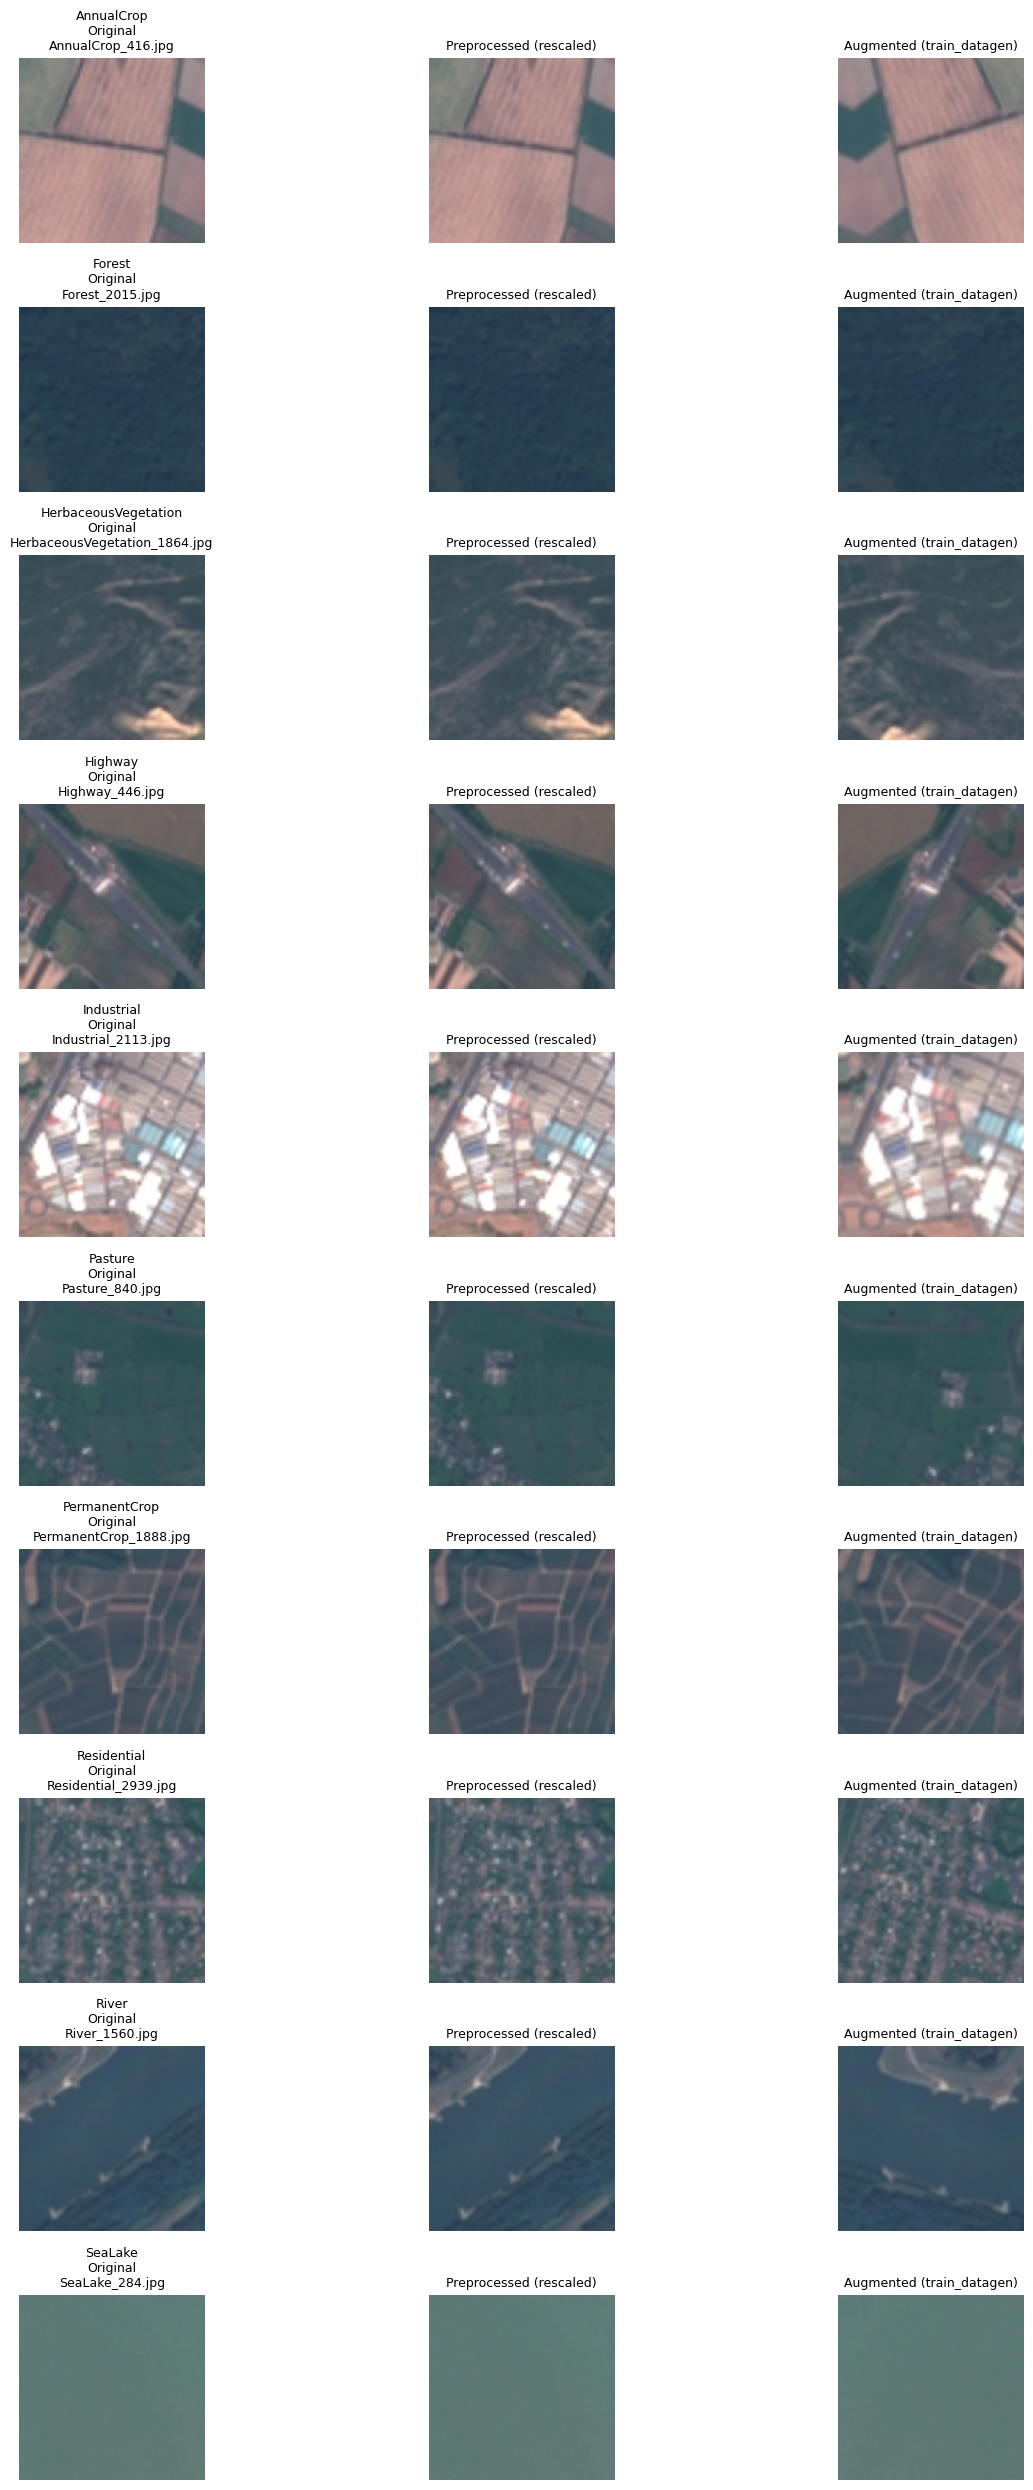

In [ ]:
# Display one example per class: Original | Preprocessed (rescaled) | Augmented (random)
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

# Safety checks (assume your variables exist)
assert 'DATASET_PATH' in globals(), "DATASET_PATH not found"
assert 'class_names' in globals(), "class_names not found"
assert 'IMG_SIZE' in globals(), "IMG_SIZE not found"

n_classes = len(class_names)
cols = 3
fig_w = 14
fig_h = max(2.5 * n_classes, 6)
fig, axes = plt.subplots(n_classes, cols, figsize=(fig_w, fig_h))
if n_classes == 1:
    axes = axes[np.newaxis, :]

for i, cls in enumerate(class_names):
    # find image files in original dataset folder
    cls_dir = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(files) == 0:
        print("No files for class", cls)
        continue
    # pick a random file to show
    fname = random.choice(files)
    path = os.path.join(cls_dir, fname)

    # load and resize for display/processing
    pil = Image.open(path).convert('RGB')
    pil_resized = pil.resize((IMG_SIZE, IMG_SIZE))
    orig_arr = np.array(pil_resized)  # uint8 0..255

    # Preprocessed: use test_datagen.standardize if available, else manual rescale
    if 'test_datagen' in globals() and hasattr(test_datagen, 'standardize'):
        prep = orig_arr.astype(np.float32)          # FIX: cast first
        prep = test_datagen.standardize(prep)
    else:
        prep = orig_arr.astype(np.float32) / 255.0

    # Augmented: apply a random transform from train_datagen then standardize
    if 'train_datagen' in globals() and hasattr(train_datagen, 'random_transform'):
        aug = orig_arr.astype(np.float32)            # FIX: cast first
        aug = train_datagen.random_transform(aug)
        if hasattr(train_datagen, 'standardize'):
            aug = train_datagen.standardize(aug)
    else:
        aug = prep.copy()

    # Clip to [0,1] for plotting floats
    def to_plot(img):
        if img.dtype == np.uint8:
            return img
        img = np.array(img, dtype=np.float32)
        if img.max() > 1.0:
            img = img / 255.0
        return np.clip(img, 0.0, 1.0)

    # Plot Original
    ax = axes[i, 0] if n_classes > 1 else axes[0]
    ax.imshow(to_plot(orig_arr))
    ax.set_title(f"{cls}\nOriginal\n{fname}", fontsize=9)
    ax.axis('off')

    # Plot Preprocessed
    ax = axes[i, 1] if n_classes > 1 else axes[1]
    ax.imshow(to_plot(prep))
    ax.set_title("Preprocessed (rescaled)", fontsize=9)
    ax.axis('off')

    # Plot Augmented
    ax = axes[i, 2] if n_classes > 1 else axes[2]
    ax.imshow(to_plot(aug))
    ax.set_title("Augmented (train_datagen)", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Model architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(img_size=(128,128), num_classes=10):
    inputs = layers.Input(shape=(*img_size,3))

    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # residual block
    def residual_block(x, filters, downsample=False):
        shortcut = x
        strides = 2 if downsample else 1

        y = layers.Conv2D(filters, 3, strides=strides, padding='same', use_bias=False)(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)

        y = layers.Conv2D(filters, 3, padding='same', use_bias=False)(y)
        y = layers.BatchNormalization()(y)

        if downsample or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', use_bias=False)(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        out = layers.add([y, shortcut])
        out = layers.Activation('relu')(out)
        return out

    # Residual stages
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)

    # simple spatial attention
    # Provide explicit output_shape so Keras can infer shapes
    avg = layers.Lambda(lambda v: tf.reduce_mean(v, axis=-1, keepdims=True),
                        output_shape=lambda s: s[:-1] + (1,))(x)
    maxp = layers.Lambda(lambda v: tf.reduce_max(v, axis=-1, keepdims=True),
                         output_shape=lambda s: s[:-1] + (1,))(x)
    concat = layers.Concatenate(axis=-1)([avg, maxp])
    att = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)
    x = layers.multiply([x, att])

    x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='eurosat_gen_model_noSE')

# quick build/test
model = build_model((128,128), 10)
model.summary()

Model: "eurosat_gen_model_noSE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     73,728 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    147,456 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      8,192 │ activation_2[0][

 Total params: 1,670,189 (6.37 MB)

 Trainable params: 1,665,965 (6.36 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [ ]:
# compile - use categorical_crossentropy if your generator yields one-hot labels
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',   # or 'sparse_categorical_crossentropy' if using sparse labels
    metrics=['accuracy']
)

# 4. Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

MODEL_SAVE = "eurosat_kaggle_best.keras"
callbacks = [
    ModelCheckpoint(MODEL_SAVE, save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

steps_per_epoch = train_gen.samples // BATCH_SIZE
validation_steps = max(1, val_gen.samples // BATCH_SIZE)

In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=150,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7673 - loss: 0.6617

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


295/295 ━━━━━━━━━━━━━━━━━━━━ 157s 487ms/step - accuracy: 0.7674 - loss: 0.6615 - val_accuracy: 0.2188 - val_loss: 4.8787 - learning_rate: 1.0000e-04
Epoch 2/150
  1/295 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.7500 - loss: 0.7666

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7500 - loss: 0.7666 - val_accuracy: 0.2210 - val_loss: 4.7853 - learning_rate: 1.0000e-04
Epoch 3/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 93s 316ms/step - accuracy: 0.8049 - loss: 0.5634 - val_accuracy: 0.4775 - val_loss: 2.5510 - learning_rate: 1.0000e-04
Epoch 4/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7500 - loss: 0.6064 - val_accuracy: 0.5086 - val_loss: 2.1946 - learning_rate: 1.0000e-04
Epoch 5/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 96s 324ms/step - accuracy: 0.8352 - loss: 0.4781 - val_accuracy: 0.7390 - val_loss: 0.8078 - learning_rate: 1.0000e-04
Epoch 6/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8594 - loss: 0.5030 - val_accuracy: 0.7135 - val_loss: 0.8328 - learning_rate: 1.0000e-04
Epoch 7/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 90s 306ms/step - accuracy: 0.8537 - loss: 0.4374 - val_accuracy: 0.7109 - val_loss: 1.1326 - learning_rate: 1.0000e-04
Epoch 8/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - ac

In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=150,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 92s 312ms/step - accuracy: 0.9214 - loss: 0.2253 - val_accuracy: 0.6613 - val_loss: 1.2503 - learning_rate: 5.0000e-05
Epoch 2/150
  1/295 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.8750 - loss: 0.3589

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8750 - loss: 0.3589 - val_accuracy: 0.6019 - val_loss: 1.6642 - learning_rate: 5.0000e-05
Epoch 3/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 95s 322ms/step - accuracy: 0.9270 - loss: 0.2157 - val_accuracy: 0.7199 - val_loss: 1.1352 - learning_rate: 5.0000e-05
Epoch 4/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9375 - loss: 0.2172 - val_accuracy: 0.8198 - val_loss: 0.5776 - learning_rate: 5.0000e-05
Epoch 5/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 103s 347ms/step - accuracy: 0.9313 - loss: 0.2003 - val_accuracy: 0.8730 - val_loss: 0.3927 - learning_rate: 5.0000e-05
Epoch 6/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9375 - loss: 0.1481 - val_accuracy: 0.8778 - val_loss: 0.3584 - learning_rate: 5.0000e-05
Epoch 7/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 92s 312ms/step - accuracy: 0.9313 - loss: 0.1954 - val_accuracy: 0.7256 - val_loss: 1.2695 - learning_rate: 5.0000e-05
Epoch 8/150
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - a

In [ ]:
# Save history
import json

with open('training_history".json', 'w') as f:
    json.dump(history.history, f)

# 5. Evaluation

In [ ]:
import os, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import tensorflow as tf

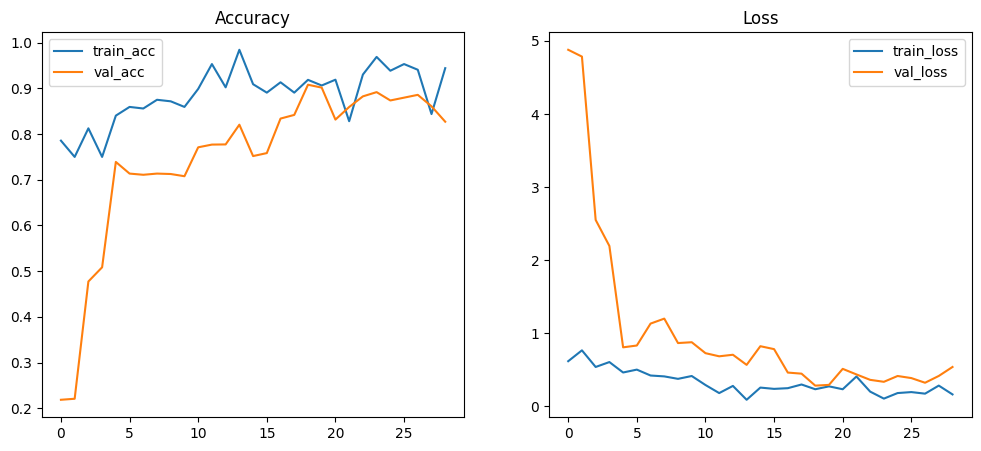

In [ ]:
# Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

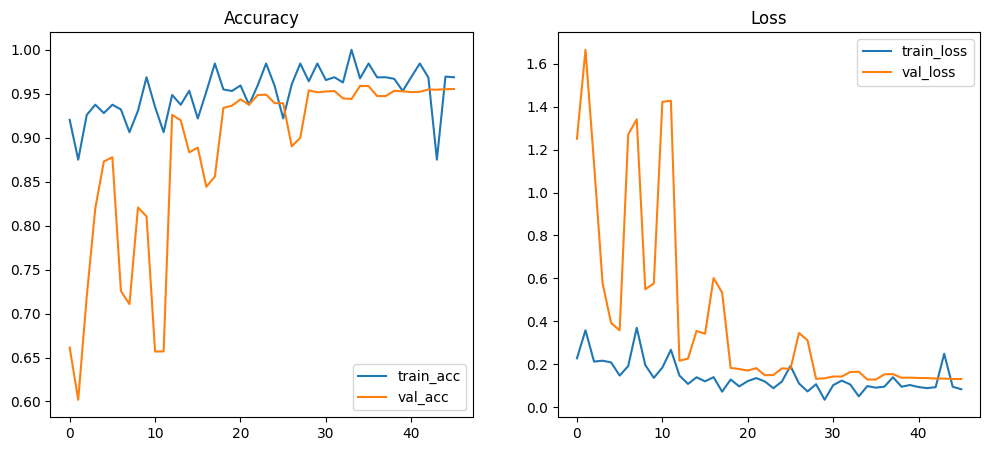

In [ ]:
# Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
# Load best weights (if saved)
if os.path.exists(MODEL_SAVE):
    model.load_weights(MODEL_SAVE)

In [ ]:
# Ensure test_gen yields from start
test_gen.reset()

# Evaluate on held-out test set (let Keras handle iteration)
print("Evaluating on test set: samples =", test_gen.samples)
test_metrics = model.evaluate(test_gen, verbose=1)
print("Test metrics (loss, accuracy):", test_metrics)

Evaluating on test set: samples = 2700
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9541 - loss: 0.1262
Test metrics (loss, accuracy): [0.13541436195373535, 0.9518518447875977]


In [ ]:
# Classification report & confusion matrix

# Reset generator to start
test_gen.reset()

# Predict on the FULL test set (no steps argument)
y_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_probs, axis=1)

# Ground truth labels
y_true = np.array(test_gen.classes)

# Trim if necessary
if len(y_pred) > len(y_true):
    y_pred = y_pred[:len(y_true)]
elif len(y_pred) < len(y_true):
    y_true = y_true[:len(y_pred)]

print("Pred shape:", y_pred.shape)
print("True shape:", y_true.shape)
print("Unique true labels:", np.unique(y_true))
print("Unique predicted labels:", np.unique(y_pred))

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Pred shape: (2700,)
True shape: (2700,)
Unique true labels: [0 1 2 3 4 5 6 7 8 9]
Unique predicted labels: [0 1 2 3 4 5 6 7 8 9]
Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.97      0.93       300
              Forest       0.99      0.99      0.99       300
HerbaceousVegetation       0.96      0.88      0.92       300
             Highway       0.97      0.93      0.95       250
          Industrial       0.96      0.96      0.96       250
             Pasture       0.94      0.96      0.95       200
       PermanentCrop       0.89      0.92      0.90       250
         Residential       0.98      1.00      0.99       300
               River       0.94      0.92      0.93       250
             SeaLake       0.99      0.99      0.99       300

            accuracy                           0.95      2700
           macro avg       0.95      0.95      0.95      2700


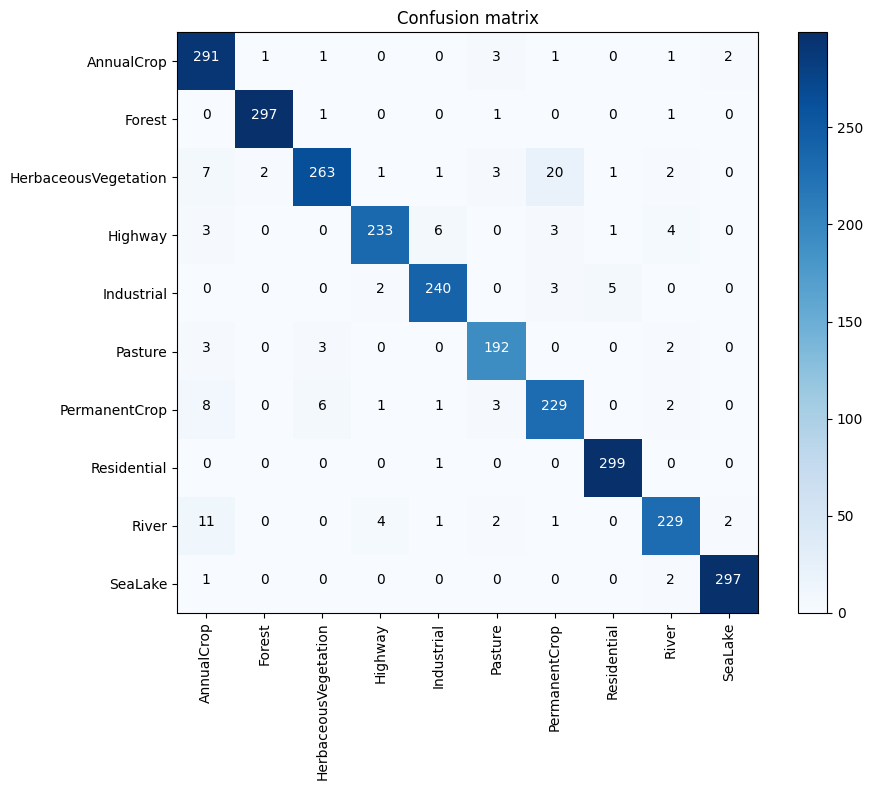

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

In [ ]:
# Quick sample predictions and Grad-CAM using test_gen

# Find last conv layer name
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
print('Last conv layer for Grad-CAM:', last_conv_layer_name)

# Prepare a batch for visualization — reset to be safe
test_gen.reset()
imgs_batch, labs_batch = next(test_gen)  # numpy arrays
n_show = min(8, imgs_batch.shape[0])
examples = imgs_batch[:n_show]   # floats in [0,1] since datagen.rescale=1./255
true_labels = np.argmax(labs_batch[:n_show], axis=1)

Last conv layer for Grad-CAM: conv2d_11


In [ ]:
# Predictions on those examples
preds = model.predict(examples)
pred_labels = np.argmax(preds, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


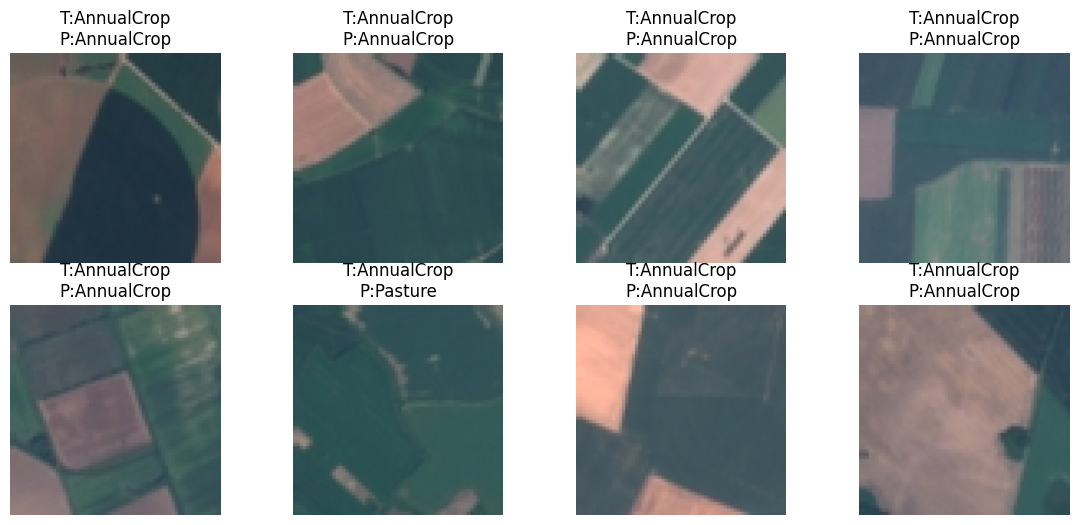

In [ ]:
# Show images with true/pred labels
plt.figure(figsize=(14,6))
for i, (img, t, p) in enumerate(zip(examples, true_labels, pred_labels)):
    plt.subplot(2,4,i+1)
    plt.axis('off')
    plt.title(f'T:{class_names[t]}\nP:{class_names[p]}')
    plt.imshow(img)
plt.show()

# 6. Grad-CAM Explainable AI

In [ ]:
# Grad-CAM implementation
def make_gradcam_heatmap(img_array, model, last_conv_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [ ]:
def overlay_heatmap(img, heatmap, alpha=0.4):
    # img: HxWx3 in 0..1
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = heatmap.astype(np.float32) / 255.0
    combined = img * (1 - alpha) + heatmap * alpha
    combined = np.clip(combined, 0, 1)
    return combined

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)


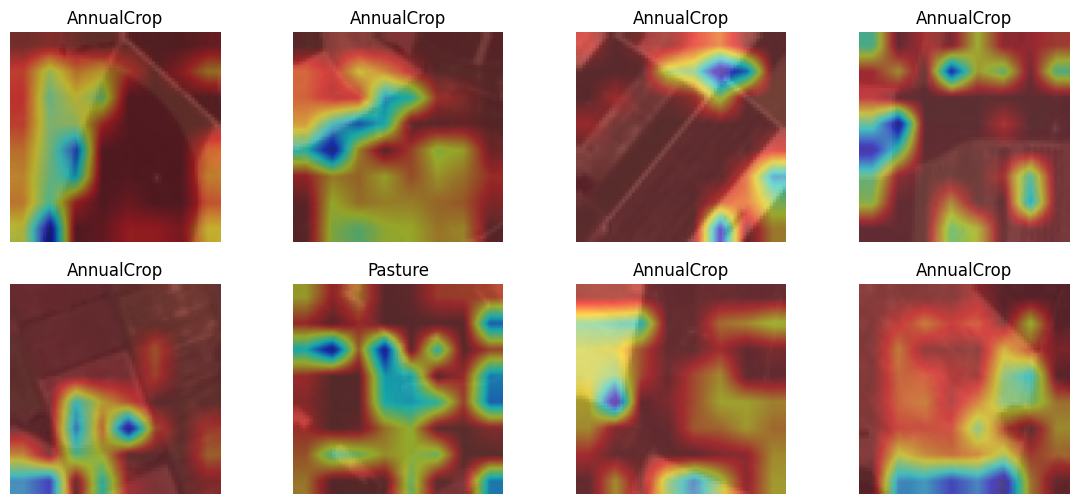

In [ ]:
# Generate Grad-CAM overlays for the selected examples
plt.figure(figsize=(14,6))
for i, (img, p) in enumerate(zip(examples, pred_labels)):
    inp = np.expand_dims(img, axis=0)  # shape 1xHxWx3
    heatmap = make_gradcam_heatmap(inp, model, last_conv_layer_name, pred_index=int(p))
    over = overlay_heatmap(img, heatmap, alpha=0.5)
    plt.subplot(2,4,i+1)
    plt.axis('off')
    plt.title(class_names[p])
    plt.imshow(over)
plt.show()